# Conteo de girasoles en video de dron

Utiliza el mejor modelo entrenado (YOLO11s SGD) con tracking para contar girasoles únicos a lo largo del video.

In [ ]:
from ultralytics import YOLO
import os

MODEL_PATH = "models/yolo11s_sgd-4/best.pt"
VIDEO_PATH = "media/video_dron.mp4"
CONF = 0.25

assert os.path.exists(MODEL_PATH), f"No se encontró el modelo: {MODEL_PATH}"
assert os.path.exists(VIDEO_PATH), f"No se encontró el video: {VIDEO_PATH}"

In [17]:
model = YOLO(MODEL_PATH)

## Tracking frame a frame

Cada girasol recibe un ID único la primera vez que aparece. El mismo girasol no se cuenta dos veces aunque permanezca visible en múltiples frames.

In [18]:
import cv2
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_AVI = os.path.join(OUTPUT_DIR, "deteccion.avi")

cap = cv2.VideoCapture(VIDEO_PATH)
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(OUTPUT_AVI, cv2.VideoWriter_fourcc(*"XVID"), fps, (width, height))

ids_vistos      = set()
conteo_por_frame = []
frame_idx       = 0

BAR_H     = 40
BOX_COLOR = (255, 80, 0)
BOX_W     = 1

while True:
    ok, frame = cap.read()
    if not ok:
        break

    results = model.track(
        source=frame,
        conf=CONF,
        tracker="bytetrack.yaml",
        persist=True,
        verbose=False,
    )
    r = results[0]

    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cv2.rectangle(frame, (x1, y1), (x2, y2), BOX_COLOR, BOX_W)

    cant_frame = len(r.boxes)
    conteo_por_frame.append(cant_frame)
    if r.boxes.id is not None:
        for tid in r.boxes.id.tolist():
            ids_vistos.add(int(tid))

    overlay = frame.copy()
    cv2.rectangle(overlay, (0, height - BAR_H), (width, height), (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    texto = f"En pantalla: {cant_frame}   |   Total vistos: {len(ids_vistos)}"
    cv2.putText(frame, texto, (12, height - 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)

    writer.write(frame)
    frame_idx += 1

cap.release()
writer.release()

print(f"Frames procesados       : {frame_idx}")
print(f"Girasoles únicos vistos : {len(ids_vistos)}")
print(f"Promedio por frame      : {sum(conteo_por_frame)/len(conteo_por_frame):.1f}")
print(f"Máximo en un frame      : {max(conteo_por_frame)}")
print(f"Video guardado en       : {OUTPUT_AVI}")

Frames procesados       : 204
Girasoles únicos vistos : 610
Promedio por frame      : 129.9
Máximo en un frame      : 226
Video guardado en       : outputs/deteccion.avi


## Distribución de detecciones por frame

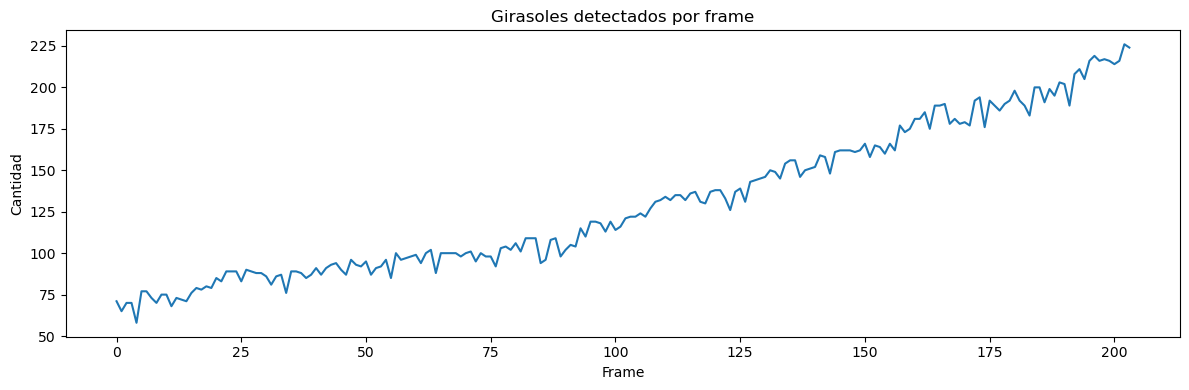

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(conteo_por_frame)
plt.title("Girasoles detectados por frame")
plt.xlabel("Frame")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

## Video de salida

El video con bounding boxes y contadores se guarda en `outputs/`.

## Exportar a MP4 (H.264)

In [20]:
import subprocess
import os

mp4_path = OUTPUT_AVI.replace(".avi", ".mp4")

cmd = [
    "ffmpeg", "-y",
    "-i", OUTPUT_AVI,
    "-c:v", "libx264",
    "-crf", "23",
    "-preset", "fast",
    mp4_path
]

print(f"Convirtiendo a MP4 H.264 ...")
subprocess.run(cmd, check=True)

size_avi = os.path.getsize(OUTPUT_AVI) / (1024**2)
size_mp4 = os.path.getsize(mp4_path)  / (1024**2)
print(f"Listo. AVI: {size_avi:.1f} MB → MP4: {size_mp4:.1f} MB")
print(f"Guardado en: {mp4_path}")

Convirtiendo a MP4 H.264 ...


ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

Listo. AVI: 16.9 MB → MP4: 5.3 MB
Guardado en: outputs/deteccion.mp4


[out#0/mp4 @ 0x59cedaf3e840] video:5465kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.051433%
frame=  204 fps=171 q=-1.0 Lsize=    5467kB time=00:00:06.70 bitrate=6684.8kbits/s speed=5.62x    
[libx264 @ 0x59cedafaf500] frame I:1     Avg QP:24.85  size: 81027
[libx264 @ 0x59cedafaf500] frame P:126   Avg QP:25.69  size: 35992
[libx264 @ 0x59cedafaf500] frame B:77    Avg QP:30.71  size: 12714
[libx264 @ 0x59cedafaf500] consecutive B-frames: 37.3% 28.4% 26.5%  7.8%
[libx264 @ 0x59cedafaf500] mb I  I16..4:  4.1% 89.0%  6.9%
[libx264 @ 0x59cedafaf500] mb P  I16..4:  0.5%  3.7%  1.1%  P16..4: 36.8% 27.6% 16.9%  0.0%  0.0%    skip:13.4%
[libx264 @ 0x59cedafaf500] mb B  I16..4:  0.2%  0.9%  0.3%  B16..8: 27.9% 16.1%  1.9%  direct: 8.1%  skip:44.6%  L0:41.1% L1:49.0% BI: 9.9%
[libx264 @ 0x59cedafaf500] 8x8 transform intra:72.0% inter:52.8%
[libx264 @ 0x59cedafaf500] coded y,uvDC,uvAC intra: 72.4% 71.8% 26.7% inter: 29.6% 38.7% 23.9%
[libx264 @ 0x59cedafaf500] 